## Tennis Versus (02 - restructuring the data and removing some unneeded features)

We have saved our work from ```01_data_exploration.ipynb``` into ```cleaned_matches_01done.parquet```.

We can now use our DataFrame from 01 here. We will now restructure the data so it will actually be useful with our model.

In [1]:
# data analytics + math
import pandas as pd 
import numpy as np 

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# other stuff used for later (need sci-kit learn too)
import xgboost # just installed it using !pip install

# set some parameters for pandas to view the data a bit better
pd.set_option('display.max_columns', 50) # see ALL columns
pd.set_option('display.width', 150)

df = pd.read_parquet('cleaned_matches_01done.parquet')


### renaming + deleting columns

there's a lot of columns in this DataFrame. Some seem more useful than others.

for example, ```tourney_id``` and player id are just identifiers - not useful for our model.
```winner_seed``` ```winner_entry``` is also not that important.

Most importantly, our dataset inherently labels the winner using the column names already. 
We want to separate this so our model doesn't take that into account.

What we want is more of a ```player_a``` and ```player_b``` and a ```label``` column signifying who won. 

In our case, ```label``` will basically be asking: "Did player A win?". ```1``` if player A wins, and ```0``` if player A loses (or player B wins).

#### important side note

ok, so we will rename ```winner_name``` --> ```player_a``` and ```loser_name``` --> ```player_b```. <br>
Then, ```label``` will be all ```1``` because we have constructed it so that player A is the winner.

Our model will simply always predict ```1``` because that's all there is.

Thus, we also need to add a "flipped" direction. In addition to what we did above, we will also add: <br>
```loser_name``` --> ```player_a``` and ```winner_name``` --> ```player_b```. Then ```label``` will be  ```0``` because player A didn't win.

Now, the model will actually have 0s and 1s to work with and figure out which features are most important and correlate the most.

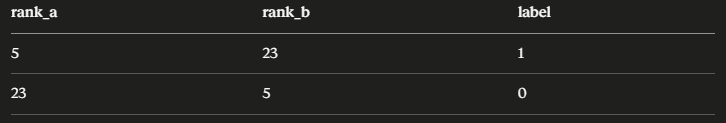

is much more useful than

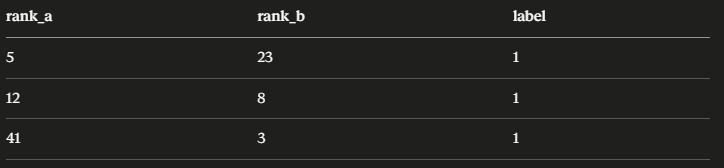

because there is now actually a way for our model to predict our label to be 0 or 1.

In [2]:
def restructure_matches(df):

    # Original direction: player_a = winner, label = 1
    df_a = pd.DataFrame({
        'tourney_date':  df['tourney_date'],
        'tourney_name':  df['tourney_name'],
        'tourney_level': df['tourney_level'],
        'surface':       df['surface'],
        'round':         df['round'],
        'best_of':       df['best_of'],
        'player_a':      df['winner_name'],
        'player_b':      df['loser_name'],
        'rank_a':        df['winner_rank'],
        'rank_b':        df['loser_rank'],
        'age_a':         df['winner_age'],
        'age_b':         df['loser_age'],
        'svpt_a':        df['w_svpt'],
        'svpt_b':        df['l_svpt'],
        'firstIn_a':     df['w_1stIn'],
        'firstIn_b':     df['l_1stIn'],
        'firstWon_a':    df['w_1stWon'],
        'firstWon_b':    df['l_1stWon'],
        'bpSaved_a':     df['w_bpSaved'],
        'bpSaved_b':     df['l_bpSaved'],
        'bpFaced_a':     df['w_bpFaced'],
        'bpFaced_b':     df['l_bpFaced'],
        'label':         1
    })

    # Flipped direction: player_a = loser, label = 0
    df_b = pd.DataFrame({
        'tourney_date':  df['tourney_date'],
        'tourney_name':  df['tourney_name'],
        'tourney_level': df['tourney_level'],
        'surface':       df['surface'],
        'round':         df['round'],
        'best_of':       df['best_of'],
        'player_a':      df['loser_name'],
        'player_b':      df['winner_name'],
        'rank_a':        df['loser_rank'],
        'rank_b':        df['winner_rank'],
        'age_a':         df['loser_age'],
        'age_b':         df['winner_age'],
        'svpt_a':        df['l_svpt'],
        'svpt_b':        df['w_svpt'],
        'firstIn_a':     df['l_1stIn'],
        'firstIn_b':     df['w_1stIn'],
        'firstWon_a':    df['l_1stWon'],
        'firstWon_b':    df['w_1stWon'],
        'bpSaved_a':     df['l_bpSaved'],
        'bpSaved_b':     df['w_bpSaved'],
        'bpFaced_a':     df['l_bpFaced'],
        'bpFaced_b':     df['w_bpFaced'],
        'label':         0
    })

    # merge
    result = pd.concat([df_a, df_b], ignore_index=True)

    # at this point, it will be all label 1s then all label 0s
    # here, we sort it back into chronological order
    result = result.sort_values('tourney_date').reset_index(drop=True)
    return result

data = restructure_matches(df)

print(data['label'].value_counts())

label
1    25210
0    25210
Name: count, dtype: int64


### adding useful features

it's time to add some useful statistics to help our model predict better.

#### Important (imo)
- difference in ranks
- H2H between the two players
- player's recent form overall (recently playing good or bad?)
  - recent form surface-wise too
- service hold rate + break rate


#### Can be added later
- more specific serve stats (1st serve, 2nd serve percentages)
- winrate for specific level of tourney (Grandslams, Masters, 500s...)

In [3]:
# difference in ranks
data['rank_diff'] = data['rank_a'] - data['rank_b'] # negative should be 1, positive should be 0

In [4]:
# recent tennis form (on a hot streak or not)
def find_recent_forms(data, last_N=10): # default - last 10 matches

    # NOTE: the label is 1 if player A wins, 0 if player A loses
    # thus, to look at all the games of a certain player, we need to find his name on the 'player_a' column
    
    form_a, form_b = [], [] # will be the columns at the end of the loop
    
    # find player A's most recent 10 matches
    for i, row in data.iterrows():
        # use bitwise & operator, can compare datetime using <,>,==, etc.
        past_a = data[(data['player_a'] == row['player_a']) & (data['tourney_date'] < row['tourney_date'])].tail(last_N)
        past_b = data[(data['player_a'] == row['player_b']) & (data['tourney_date'] < row['tourney_date'])].tail(last_N)

        if len(past_a) >= 3: # more than 3 matches
            form_a.append(past_a['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_a.append(0.5) # default - give equal winning chances to both players\\

        if len(past_b) >= 3: # only 2 matches
            form_b.append(past_b['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_b.append(0.5) # default - give equal winning chances to both players
            
    data['form_a'] = form_a
    data['form_b'] = form_b

# call the function to actually make the new features
find_recent_forms(data)

data.tail()


,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b
50415,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6
50416,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8
50417,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7
50418,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8
50419,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7


In [5]:
# the same as above but taking into account surface
def find_recent_forms_surface(data, last_N=10):
    form_a, form_b = [], [] # will be the columns at the end of the loop
    
    # find player A's most recent 10 matches
    for i, row in data.iterrows():
        # use bitwise & operator, can compare datetime using <,>,==, etc.
        matchingName = data['player_a'] == row['player_a']
        priorTourney = data['tourney_date'] < row['tourney_date']
        matchingSurface = data['surface'] == row['surface']
        
        past_a = data[matchingName & priorTourney & matchingSurface].tail(last_N)
        past_b = data[matchingName & priorTourney & matchingSurface].tail(last_N)

        if len(past_a) >= 3: # more than 3 matches
            form_a.append(past_a['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_a.append(0.5) # default - give equal winning chances to both players\\

        if len(past_b) >= 3: # only 2 matches
            form_b.append(past_b['label'].mean()) # .mean() is a nice way to calculate winning percentage
        else:
            form_b.append(0.5) # default - give equal winning chances to both players
            
    data['surface_form_a'] = form_a
    data['surface_form_b'] = form_b

# call the function to actually make the new features
find_recent_forms_surface(data)
data.tail()
    

,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b
50415,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6,0.7,0.7
50416,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4
50417,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7
50418,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.8,0.8
50419,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8


In [10]:
# H2H
def h2h(data):
    res = []

    for _, row in data.iterrows():
        matchA = data['player_a'] == row['player_a']
        matchB = data['player_b'] == row['player_b']
        priorTourney = data['tourney_date'] < row['tourney_date']
        
        past = data[matchA & matchB & priorTourney]
        
        res.append(past['label'].mean() if len(past) >= 2 else 0.5)


    data['h2h_winrate_a'] = res

h2h(data)

data.tail()

,tourney_date,tourney_name,tourney_level,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard,h2h_winrate_a
50415,2026-06-20,Queen's Club,500,SF,3,Tommy Paul,Ugo Humbert,28.0,33.0,29.092,27.984,53.0,56.0,32.0,35.0,24.0,23.0,1.0,2.0,2.0,6.0,1,-5.0,0.8,0.7,0.8,0.8,7.1,5.2,1930.772404,1760.886904,1756.968148,1624.486873,169.885500,132.481275,0,1,0,1.000000
50416,2026-06-21,Halle,500,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.8,0.8,4.2,6.2,1896.856222,1900.577897,1910.009123,1699.280877,-3.721675,210.728246,0,1,0,1.000000
50417,2026-06-21,Queen's Club,500,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,7.9,5.8,1853.299843,1939.518030,1596.398377,1767.146610,-86.218186,-170.748233,0,1,0,0.714286
50418,2026-06-21,Halle,500,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,6.2,4.2,1916.406514,1881.027605,1723.947694,1885.342306,35.378909,-161.394611,0,1,0,0.000000
50419,2026-06-21,Queen's Club,500,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,5.8,7.9,1919.627079,1873.190794,1743.860709,1619.684279,46.436286,124.176430,0,1,0,0.285714


In [37]:
# finding holding + breaking rate
def hold_rate(data):
    pass

# print(data.info())

In [6]:
# actually, finding an average on how many BPs a player faces per match might be important
def bp_pressure(data, last_N=10):

    pressure_a = []
    pressure_b = []
    
    for _, row in data.iterrows():
    
        past_a = data[
            (data['player_a'] == row['player_a']) &
            (data['tourney_date'] < row['tourney_date'])
        ].tail(last_N)

        past_b = data[
            (data['player_a'] == row['player_b']) &
            (data['tourney_date'] < row['tourney_date'])
        ].tail(last_N)

        # let's say default is 5
        pressure_a.append((past_a['bpFaced_a'].sum() / len(past_a)) if len(past_a) >= 3 else 5)
        pressure_b.append((past_b['bpFaced_a'].sum() / len(past_b)) if len(past_b) >= 3 else 5)

    data['bp_pressure_a'] = pressure_a
    data['bp_pressure_b'] = pressure_b

bp_pressure(data)
data.tail()

        
    

,tourney_date,tourney_name,tourney_level,surface,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b
50415,2026-06-20,Halle,500,Grass,SF,3,Alexander Zverev,Taylor Fritz,3.0,9.0,29.166,28.643,95.0,98.0,59.0,67.0,49.0,57.0,3.0,1.0,6.0,2.0,0,-6.0,1.0,0.6,0.7,0.7,3.1,5.0
50416,2026-06-21,Queen's Club,500,Grass,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,7.9,5.8
50417,2026-06-21,Halle,500,Grass,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,6.2,4.2
50418,2026-06-21,Halle,500,Grass,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.8,0.8,4.2,6.2
50419,2026-06-21,Queen's Club,500,Grass,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,5.8,7.9


### 2nd try - implementing ELO

Since the first try didn't go too well, let's try adding an ELO feature.

"ELO" is calculated as follows:

E is expected score.

$$E = \frac{1}{1 + 10 ^ {\frac{elo_b - elo_a}{400}}}$$

and 

new_elo = old_elo + $ K * ($actual_res $ - E)$

where K is a scalar representing how much change should happen on a loss or win. Higher K means bigger change in ELO.

In [7]:
def compute_elo(matches, k=32, default_elo=1500):
    overall_ratings = {}          # player -> overall elo
    surface_ratings = {           # player -> elo per surface
        'Grass': {},
        'Clay': {},
        'Hard': {}
    }
    
    elo_a_list         = []
    elo_b_list         = []
    surface_elo_a_list = []
    surface_elo_b_list = []
    
    matches = matches.sort_values('tourney_date').reset_index(drop=True)
    
    for idx, row in matches.iterrows():
        player_a = row['player_a']
        player_b = row['player_b']
        surface  = row['surface']
        
        # Get current ratings before the match ( .get() safely retrieves and has a default value as a parameter)
        elo_a         = overall_ratings.get(player_a, default_elo)
        elo_b         = overall_ratings.get(player_b, default_elo)
        surface_elo_a = surface_ratings[surface].get(player_a, default_elo)
        surface_elo_b = surface_ratings[surface].get(player_b, default_elo)
        
        # Record pre-match values — these go into the model
        elo_a_list.append(elo_a)
        elo_b_list.append(elo_b)
        surface_elo_a_list.append(surface_elo_a)
        surface_elo_b_list.append(surface_elo_b)
        
        # Expected scores
        overall_expected_a = 1 / (1 + 10 ** ((elo_b - elo_a) / 400))
        surface_expected_a = 1 / (1 + 10 ** ((surface_elo_b - surface_elo_a) / 400))
        
        # Actual result
        actual_a = row['label']
        actual_b = 1 - actual_a
        
        # Update overall ratings
        overall_ratings[player_a] = elo_a + k * (actual_a - overall_expected_a)
        overall_ratings[player_b] = elo_b + k * (actual_b - (1 - overall_expected_a))
        
        # Update surface ratings
        surface_ratings[surface][player_a] = surface_elo_a + k * (actual_a - surface_expected_a)
        surface_ratings[surface][player_b] = surface_elo_b + k * (actual_b - (1 - surface_expected_a))

        # at this point, elo_a_list is the ELO we know before the match so we record that
        # overall_ratings is the rolling list we keep updating with ELOs
    
    matches['elo_a']          = elo_a_list
    matches['elo_b']          = elo_b_list
    matches['surface_elo_a']  = surface_elo_a_list
    matches['surface_elo_b']  = surface_elo_b_list
    matches['elo_diff']         = matches['elo_a'] - matches['elo_b']
    matches['surface_elo_diff'] = matches['surface_elo_a'] - matches['surface_elo_b']

    
    
    return matches

data = compute_elo(data)

# finding highest ELOs lol
# highest peaks
data.groupby('player_a')['elo_a'].max().sort_values(ascending=False).head(10)


player_a
Jannik Sinner         2413.129249
Carlos Alcaraz        2368.192472
Novak Djokovic        2321.474743
Rafael Nadal          2230.418007
Daniil Medvedev       2187.679237
Alexander Zverev      2165.744438
Roger Federer         2142.281598
Jack Draper           2096.837547
Stefanos Tsitsipas    2095.854634
Grigor Dimitrov       2089.937820
Name: elo_a, dtype: float64

### finalizing dataset

ok, now we finalize our features. Drop the columns that aren't useful to our model. [One hot encode](https://www.geeksforgeeks.org/machine-learning/ml-one-hot-encoding/) the surface (basically turn text into numbers so the model can actually find it useful).

In [8]:
# find any null values
# print(data.isnull().sum())

# manually fix ages of some players (botic VDZ and martin damm ??)
data.loc[(data['player_b'] == 'Botic Van De Zandschulp') & (data['tourney_name'] == 'Hong Kong'), 'age_b'] = 30.5
data.loc[(data['player_b'] == 'Martin Damm') & (data['age_b'].isnull()), 'age_b'] = 22.5

# drop the rest of the null ages
data = data.dropna(subset=['age_a', 'age_b'])


In [9]:
# One hot encoding
# in pandas, use .get_dummies()
data = pd.get_dummies(data, columns=['surface'], prefix='surface')

# turn the T/F into 1/0
data['surface_Grass'] = data['surface_Grass'].astype(int)
data['surface_Clay'] = data['surface_Clay'].astype(int)
data['surface_Hard'] = data['surface_Hard'].astype(int)

data.tail()


,tourney_date,tourney_name,tourney_level,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard
50415,2026-06-20,Queen's Club,500,SF,3,Tommy Paul,Ugo Humbert,28.0,33.0,29.092,27.984,53.0,56.0,32.0,35.0,24.0,23.0,1.0,2.0,2.0,6.0,1,-5.0,0.8,0.7,0.8,0.8,7.1,5.2,1930.772404,1760.886904,1756.968148,1624.486873,169.885500,132.481275,0,1,0
50416,2026-06-21,Halle,500,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.8,0.8,4.2,6.2,1896.856222,1900.577897,1910.009123,1699.280877,-3.721675,210.728246,0,1,0
50417,2026-06-21,Queen's Club,500,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,7.9,5.8,1853.299843,1939.518030,1596.398377,1767.146610,-86.218186,-170.748233,0,1,0
50418,2026-06-21,Halle,500,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,6.2,4.2,1916.406514,1881.027605,1723.947694,1885.342306,35.378909,-161.394611,0,1,0
50419,2026-06-21,Queen's Club,500,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,5.8,7.9,1919.627079,1873.190794,1743.860709,1619.684279,46.436286,124.176430,0,1,0


### making a player lookup table 

ultimately, I want to choose 2 players and give it to my model and it will spit out a probability.

however, right now, it takes in a bunch of numerical data like ELO, rank_diff, recent_form, etc. A user won't be able to supply that!

So right now, I will take the most recent match data for every player -- and that will make up the lookup table.

In [11]:
data.tail()

,tourney_date,tourney_name,tourney_level,round,best_of,player_a,player_b,rank_a,rank_b,age_a,age_b,svpt_a,svpt_b,firstIn_a,firstIn_b,firstWon_a,firstWon_b,bpSaved_a,bpSaved_b,bpFaced_a,bpFaced_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard,h2h_winrate_a
50415,2026-06-20,Queen's Club,500,SF,3,Tommy Paul,Ugo Humbert,28.0,33.0,29.092,27.984,53.0,56.0,32.0,35.0,24.0,23.0,1.0,2.0,2.0,6.0,1,-5.0,0.8,0.7,0.8,0.8,7.1,5.2,1930.772404,1760.886904,1756.968148,1624.486873,169.885500,132.481275,0,1,0,1.000000
50416,2026-06-21,Halle,500,F,3,Taylor Fritz,Frances Tiafoe,9.0,26.0,28.646,28.416,58.0,47.0,44.0,35.0,33.0,32.0,5.0,0.0,7.0,0.0,0,-17.0,0.7,0.8,0.8,0.8,4.2,6.2,1896.856222,1900.577897,1910.009123,1699.280877,-3.721675,210.728246,0,1,0,1.000000
50417,2026-06-21,Queen's Club,500,F,3,Francisco Cerundolo,Tommy Paul,27.0,28.0,27.855,29.095,126.0,105.0,75.0,57.0,50.0,40.0,8.0,8.0,10.0,12.0,1,-1.0,0.7,0.8,0.4,0.4,7.9,5.8,1853.299843,1939.518030,1596.398377,1767.146610,-86.218186,-170.748233,0,1,0,0.714286
50418,2026-06-21,Halle,500,F,3,Frances Tiafoe,Taylor Fritz,26.0,9.0,28.416,28.646,47.0,58.0,35.0,44.0,32.0,33.0,0.0,5.0,0.0,7.0,1,17.0,0.8,0.7,0.7,0.7,6.2,4.2,1916.406514,1881.027605,1723.947694,1885.342306,35.378909,-161.394611,0,1,0,0.000000
50419,2026-06-21,Queen's Club,500,F,3,Tommy Paul,Francisco Cerundolo,28.0,27.0,29.095,27.855,105.0,126.0,57.0,75.0,40.0,50.0,8.0,8.0,12.0,10.0,0,1.0,0.8,0.7,0.8,0.8,5.8,7.9,1919.627079,1873.190794,1743.860709,1619.684279,46.436286,124.176430,0,1,0,0.285714


In [43]:
# get latest data for all players
latest = (
    data.sort_values('tourney_date')
    .groupby('player_a')
    .last()
    .reset_index()
)

# get the stats
player_stats = latest[[
    'player_a',
    'rank_a',
    'age_a',
    'elo_a',
    'form_a',
    'bp_pressure_a',
]].rename(columns={
    'player_a':       'player',
    'rank_a':         'rank',
    'age_a':          'age',
    'elo_a':          'elo',
    'form_a':         'recent_form', # last 10
    'bp_pressure_a':  'bp_pressure', # last 10
})

player_stats = player_stats.set_index('player')

# add surface specific ELO stats
for surface in ['Grass', 'Clay', 'Hard']:
    recent = (
        data[data[f'surface_{surface}'] == 1] # search for just the surface
        .sort_values('tourney_date')
        .groupby('player_a')
        .last()
        .reset_index()
        )
    renamed_stats = recent[[  'player_a', 
            'surface_elo_a', 
            'surface_form_a'
        ]].rename(columns={
            'player_a':       'player',
            'surface_elo_a':  f'{surface.lower()}_elo',
            'surface_form_a': f'{surface.lower()}_form',
        }).set_index('player')
        
    player_stats = player_stats.join(renamed_stats, how='left')

player_stats.loc['Jannik Sinner']

rank              1.000000
age              24.780000
elo            2381.512589
recent_form       1.000000
bp_pressure       2.100000
grass_elo      1797.379041
grass_form        0.800000
clay_elo       2175.637974
clay_form         1.000000
hard_elo       2295.994256
hard_form         1.000000
Name: Jannik Sinner, dtype: float64

In [49]:
# checking NaN values
player_stats.isna().sum()

for surface in ['grass', 'clay', 'hard']:
    player_stats[f'{surface}_elo']  = player_stats[f'{surface}_elo'].fillna(1500) # default of 1500
    player_stats[f'{surface}_form'] = player_stats[f'{surface}_form'].fillna(0.5) # default of 0.5 recent winrate

# save to CSV file
player_stats.to_csv('player_stats.csv')

#### dropping columns

now, we drop the columns the model can't / doesn't have to know for training.

In [50]:
# make a copy just in case?
# copy = data
# copy = pd.read_parquet('data_copy.parquet')

# dropping columns
data = data.drop(columns=[
    'tourney_name',
    'tourney_level',
    'round',
    'best_of',
    'player_a',
    'player_b',
    'svpt_a',
    'svpt_b',
    'firstIn_a',
    'firstIn_b',
    'firstWon_a',
    'firstWon_b',
    'bpSaved_a',
    'bpSaved_b',
    'bpFaced_a',
    'bpFaced_b',
    'rank_a', # already have the rank_diff column
    'rank_b'
])

# all the 'dependent' variables
features = data.columns.tolist()
features.remove('label')

# testing stuff
features.remove('age_a')
features.remove('age_b')
features.remove('rank_diff')

X = data[features]
y = data['label']

# check no nulls
print(X.isnull().sum())
print(X.describe())

tourney_date        0
form_a              0
form_b              0
surface_form_a      0
surface_form_b      0
bp_pressure_a       0
bp_pressure_b       0
elo_a               0
elo_b               0
surface_elo_a       0
surface_elo_b       0
elo_diff            0
surface_elo_diff    0
surface_Clay        0
surface_Grass       0
surface_Hard        0
h2h_winrate_a       0
dtype: int64
                        tourney_date        form_a        form_b  surface_form_a  surface_form_b  bp_pressure_a  bp_pressure_b         elo_a  \
count                          50393  50393.000000  50393.000000    50393.000000    50393.000000   50393.000000   50393.000000  50393.000000   
mean   2021-10-10 20:28:34.238088448      0.496271      0.496285        0.505009        0.505009       6.618667       6.618198   1651.561830   
min              2017-01-02 00:00:00      0.000000      0.000000        0.000000        0.000000       1.000000       1.000000   1261.392836   
25%              2019-02-25 00:00:00 

In [51]:
data.tail()

,tourney_date,age_a,age_b,label,rank_diff,form_a,form_b,surface_form_a,surface_form_b,bp_pressure_a,bp_pressure_b,elo_a,elo_b,surface_elo_a,surface_elo_b,elo_diff,surface_elo_diff,surface_Clay,surface_Grass,surface_Hard,h2h_winrate_a
50415,2026-06-20,29.092,27.984,1,-5.0,0.8,0.7,0.8,0.8,7.1,5.2,1930.772404,1760.886904,1756.968148,1624.486873,169.885500,132.481275,0,1,0,1.000000
50416,2026-06-21,28.646,28.416,0,-17.0,0.7,0.8,0.8,0.8,4.2,6.2,1896.856222,1900.577897,1910.009123,1699.280877,-3.721675,210.728246,0,1,0,1.000000
50417,2026-06-21,27.855,29.095,1,-1.0,0.7,0.8,0.4,0.4,7.9,5.8,1853.299843,1939.518030,1596.398377,1767.146610,-86.218186,-170.748233,0,1,0,0.714286
50418,2026-06-21,28.416,28.646,1,17.0,0.8,0.7,0.7,0.7,6.2,4.2,1916.406514,1881.027605,1723.947694,1885.342306,35.378909,-161.394611,0,1,0,0.000000
50419,2026-06-21,29.095,27.855,0,1.0,0.8,0.7,0.8,0.8,5.8,7.9,1919.627079,1873.190794,1743.860709,1619.684279,46.436286,124.176430,0,1,0,0.285714


### we are done (for now)

We have restructured our dataset - now it should be ready for us to actually do something with it.

Once again, we save it to a parquet file into ```parquets/``` directory.


In [52]:
# save the copy just in case?
# copy.to_parquet('data_copy.parquet')

data.to_parquet('restructured_matches_02done.parquet')